# Bayesian Inference for Systems of Elementary Reactions

## Import Libraries

In [73]:
from pathlib import Path
import importlib
import json
import arviz as az
import matplotlib.pyplot as plt

from experiment_framework import load_experiment_bundle
import inference_plotting as inference_plotting_module
import inference_runner as inference_runner_module
importlib.reload(inference_plotting_module)
importlib.reload(inference_runner_module)
from inference_runner import (
    get_free_parameter_names,
    plot_parameter_marginals,
    plot_posterior_trace_diagnostics,
    plot_predictive,
    plot_priors,
    run_bayesian_inference,
    summarize_inference_metrics,
 )
from reaction_model_builder import build_ode_system_from_reactions

## Run Bayesian Analysis and Plot Diagnostics

Toggle workflow mode on to load inference data and skip to plotting

Loaded existing posterior samples (inference run skipped).

Prior samples: Test_Model/Results/Test_Model_prior_samples_pm.nc

Posterior samples: Test_Model/Results/Test_Model_posterior_samples_pm.nc


/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.62 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/opt/anaconda3/envs/Bayesian/lib/python3.13/site-packages/arviz/stats/stats.py:1652: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
k_f,7.9416,0.9596,6.2143,9.5317,0.1132,0.0514,69.9640,264.9298,1.0615
k_r,0.2597,0.1390,0.0438,0.5080,0.0092,0.0086,205.0253,143.8245,1.0265
k_cat,3.5735,0.2864,3.0830,4.1549,0.0273,0.0161,114.3516,240.7907,1.0475
k_side,0.1426,0.0082,0.1290,0.1594,0.0004,0.0003,351.5469,329.3765,1.0129



Model comparison metrics:
LOO:
Computed from 400 posterior samples and 58 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -198.63    54.40
p_loo       34.18        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.62]   (good)       46   79.3%
   (0.62, 1]   (bad)         2    3.4%
   (1, Inf)   (very bad)   10   17.2%


WAIC:
Computed from 400 posterior samples and 58 observations log-likelihood matrix.

          Estimate       SE
elpd_waic  -200.14    54.85
p_waic       35.68        -

There has been a warning during the calculation. Please check the results.

Saved posterior trace diagnostics plot: /Users/annettethompson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Jerome Michael Fox - Annie Thompson/Git Repositories/Bayesian Kinetic Model/Restructured Framework/Test_Model/Results/Test_Model_trace_plot.png

Saved posterior parameter mar

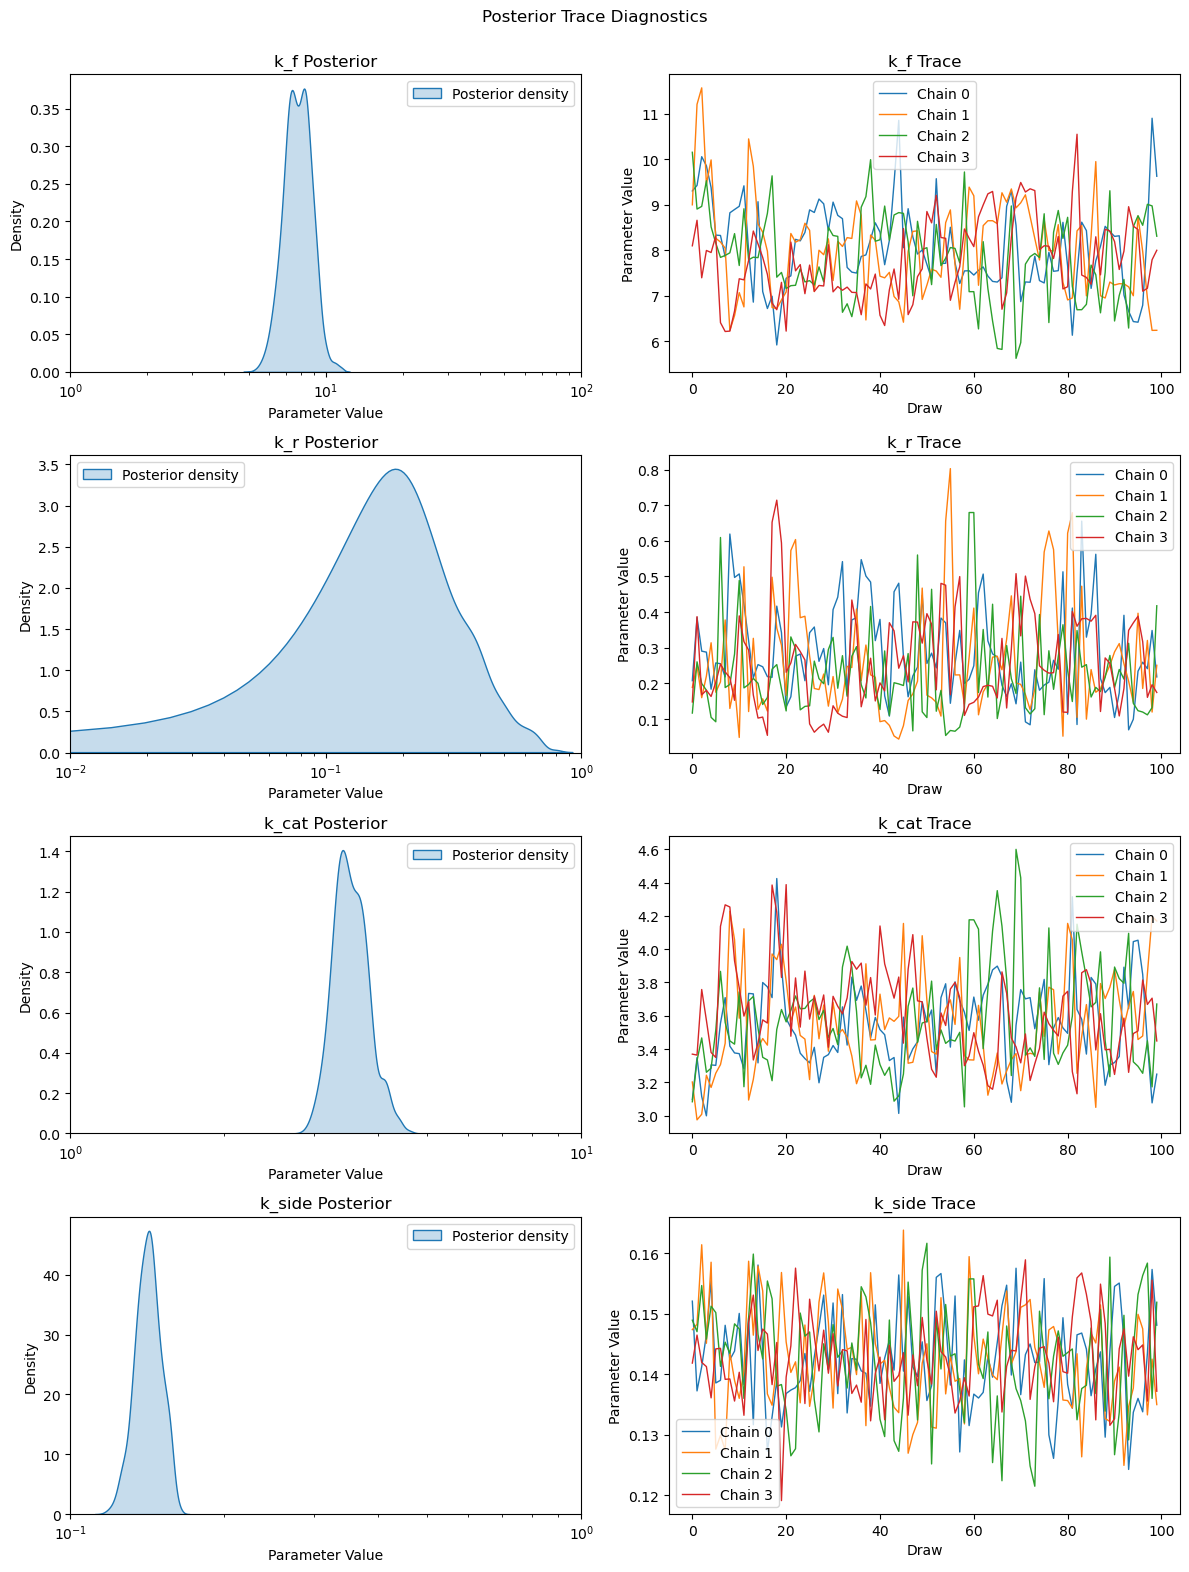

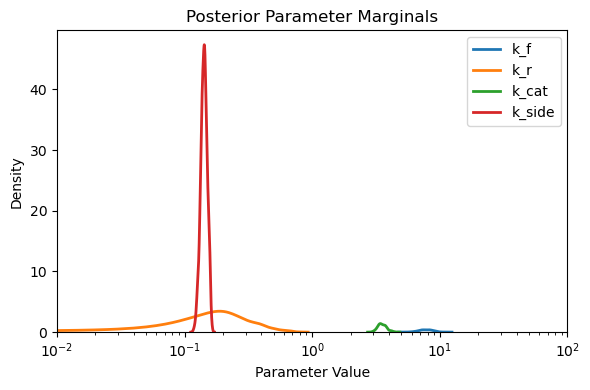

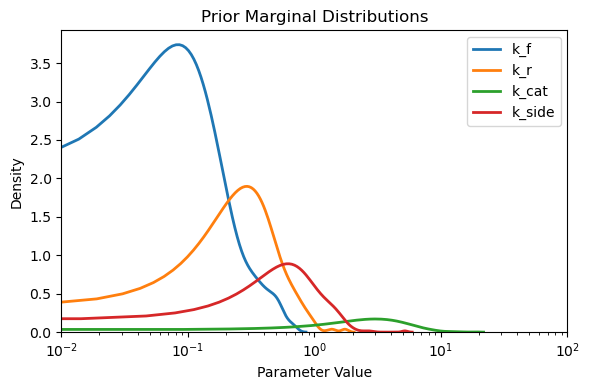

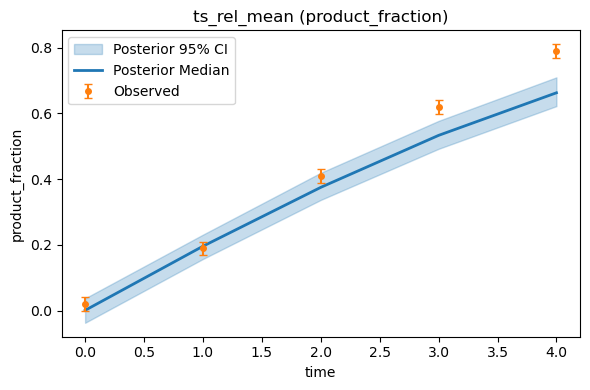

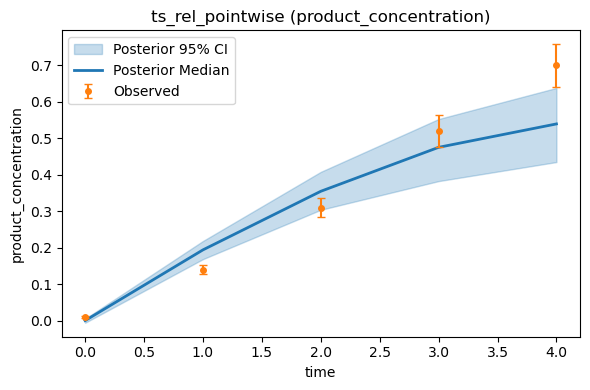

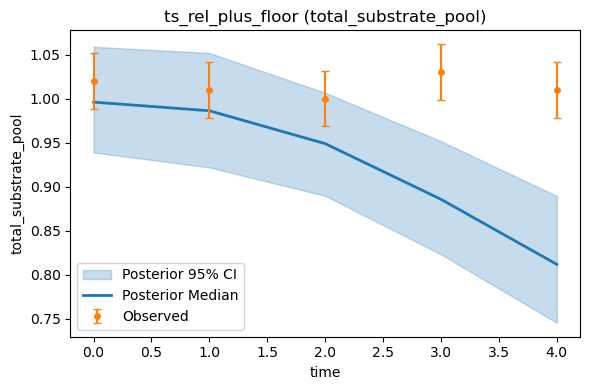

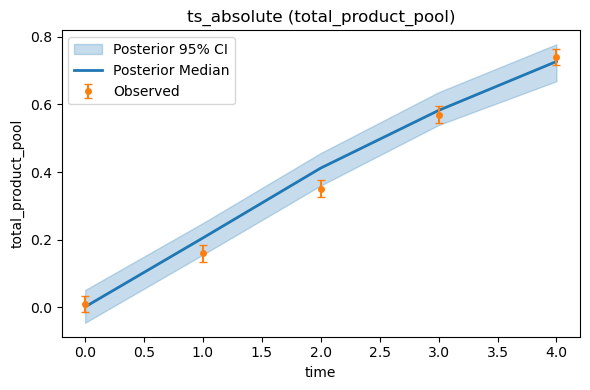

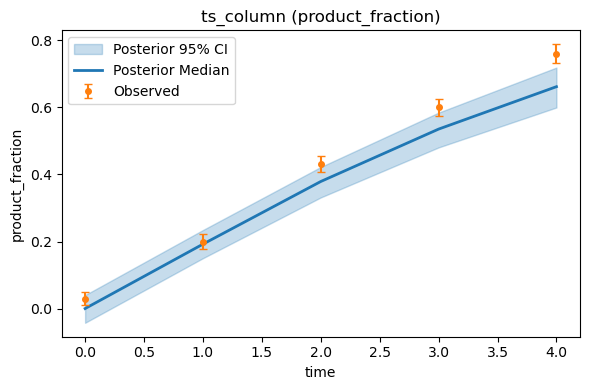

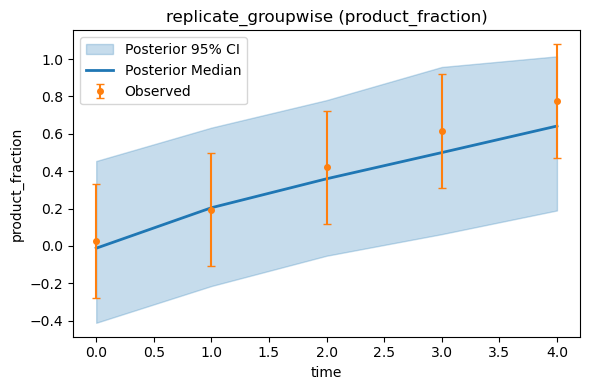

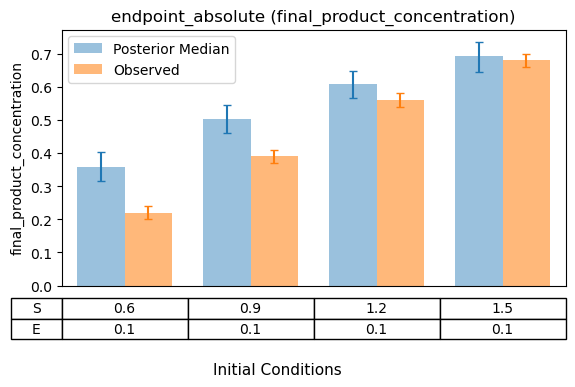

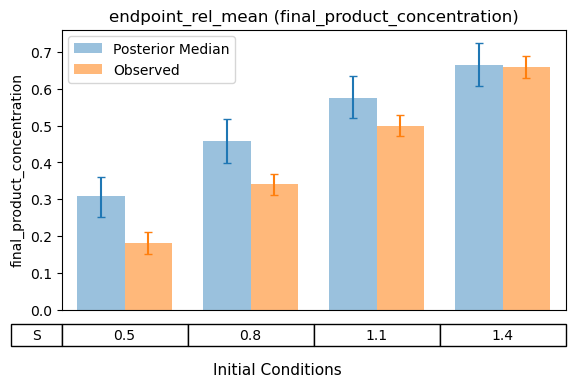

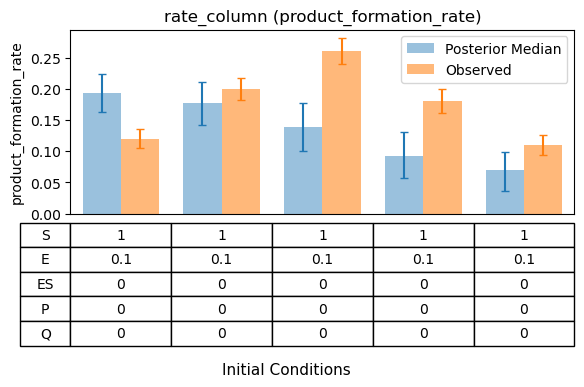

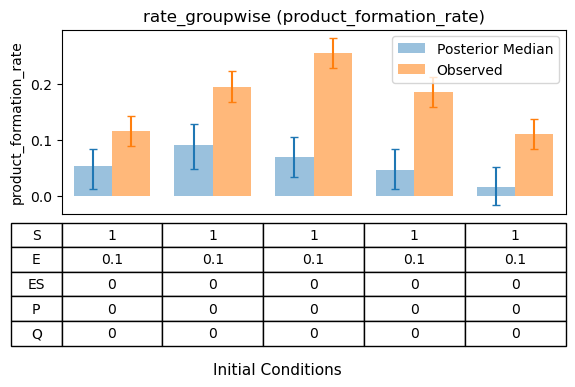

In [74]:
# Toggle workflow mode:
use_existing_results = True
use_log_param_axis = True

# Plot styling (configured in the notebook)
plt.style.use("default")
posterior_plot_color = "C0"
observed_plot_color = "C1"

# Paths for Test_Model config + inference artifacts
reactions_source = "./Test_Model/Reactions"
savedir = "./Test_Model/Results"
solver_params_file = "solver_params_test.json"
prior_samples_file = "Test_Model_prior_samples_pm.nc"
posterior_samples_file = "Test_Model_posterior_samples_pm.nc"
trace_plot_file = "Test_Model_trace_plot.png"

solver_params_candidates = [
    (Path(savedir) / solver_params_file).expanduser().resolve(),
    Path("./Test_Model") / solver_params_file,
 ]
written_solver_params_path = next(
    (path.resolve() for path in solver_params_candidates if path.exists()),
    None,
 )
if written_solver_params_path is None:
    raise FileNotFoundError(
        "Solver params file not found. Expected one of: "
        f"{solver_params_candidates[0].resolve()} or {solver_params_candidates[1].resolve()}"
    )

with open(written_solver_params_path, "r", encoding="utf-8") as solver_file:
    solver_params = json.load(solver_file)

prior_file_path = Path(savedir) / prior_samples_file
posterior_file_path = Path(savedir) / posterior_samples_file
trace_path = Path(savedir) / trace_plot_file
parameter_density_path = trace_path.with_name(f"{trace_path.stem}_hist.pdf")
prior_density_path = trace_path.with_name(f"{trace_path.stem}_prior_hist.pdf")

if not use_existing_results:
    result = run_bayesian_inference(
        solver_params_file=str(written_solver_params_path),
        reactions_source=reactions_source,
        savedir=savedir,
        prior_samples_file=prior_samples_file,
        posterior_samples_file=posterior_samples_file,
        make_trace_plot=False,
        trace_plot_file=trace_plot_file,
        use_log_param_axis=use_log_param_axis,
    )

    inference_data = result.posterior
    experiment_for_plots = result.experiment
    free_params = result.free_params
    summary_table = result.summary
    loo_result = result.loo
    waic_result = result.waic

    experiment_summary_text = result.experiment_summary
    prior_path_text = result.prior_file
    results_path_text = result.results_file
    trace_path_text = str(trace_path)
    parameter_density_path_text = str(parameter_density_path)
    prior_density_path_text = str(prior_density_path)
else:
    if not posterior_file_path.exists():
        raise FileNotFoundError(
            f"Posterior samples file not found: {posterior_file_path}. Set use_existing_results=False to run inference first."
        )

    inference_data = az.from_netcdf(posterior_file_path)

    _, species_names_for_experiment, _, _ = build_ode_system_from_reactions(reactions_source)
    experiment_for_plots = load_experiment_bundle(
        solver_params=solver_params,
        solver_params_file=str(written_solver_params_path),
        species_names=species_names_for_experiment,
    )

    free_params = get_free_parameter_names(solver_params)
    metrics = summarize_inference_metrics(inference_data, free_params)
    free_params = metrics["free_params"]
    summary_table = metrics["summary"]
    loo_result = metrics["loo"]
    waic_result = metrics["waic"]

    experiment_summary_text = "Loaded existing posterior samples (inference run skipped)."
    prior_path_text = str(prior_file_path) if prior_file_path.exists() else "Not found"
    results_path_text = str(posterior_file_path)
    trace_path_text = str(trace_path)
    parameter_density_path_text = str(parameter_density_path)
    prior_density_path_text = str(prior_density_path)

print(experiment_summary_text)
print(f"\nPrior samples: {prior_path_text}")
print(f"\nPosterior samples: {results_path_text}")

display(summary_table)

print("\nModel comparison metrics:")
print("LOO:")
print(loo_result)
print("\nWAIC:")
print(waic_result)

trace_artifacts = plot_posterior_trace_diagnostics(
    inf_data=inference_data,
    free_params=free_params,
    save_file=trace_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
parameter_marginal_artifacts = plot_parameter_marginals(
    inf_data=inference_data,
    free_params=free_params,
    save_file=parameter_density_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
prior_marginal_artifacts = plot_priors(
    inf_data=inference_data,
    free_params=free_params,
    save_file=prior_density_path_text,
    show=True,
    use_log_param_axis=use_log_param_axis,
 )
predictive_artifacts = plot_predictive(
    inf_data=inference_data,
    experiment=experiment_for_plots,
    save_dir=str(trace_path.parent),
    file_stem=str(trace_path.stem),
    show=True,
    posterior_color=posterior_plot_color,
    observed_color=observed_plot_color,
 )

if trace_artifacts.get("plot_file"):
    print(f"\nSaved posterior trace diagnostics plot: {trace_artifacts['plot_file']}")
if parameter_marginal_artifacts.get("plot_file"):
    print(
        f"\nSaved posterior parameter marginal plot: "
        f"{parameter_marginal_artifacts['plot_file']}"
    )
if prior_marginal_artifacts.get("plot_file"):
    print(f"\nSaved prior parameter marginal plot: {prior_marginal_artifacts['plot_file']}")
elif not prior_marginal_artifacts.get("prior_var_names"):
    print("\nNo matching prior variables found for plotting.")

if predictive_artifacts.get("data_vs_results_plot_files"):
    print("\nSaved predictive plots:")
    for dataset_name, plot_path in predictive_artifacts["data_vs_results_plot_files"].items():
        print(f"  {dataset_name}: {plot_path}")

plot_artifacts = {
    "trace_diagnostics": trace_artifacts,
    "parameter_marginals": parameter_marginal_artifacts,
    "prior_marginals": prior_marginal_artifacts,
    "predictive": predictive_artifacts,
}